In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.layers import Dropout,Dense,Flatten,Conv2D,MaxPool2D,Input

In [2]:
dataset_path = "dataset/train/"

image_sizes = []

label_folders = os.listdir(dataset_path)

for folder in label_folders:
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        for image_file in os.listdir(folder_path):
            image_path = os.path.join(folder_path, image_file)
            try:
                img = cv2.imread(image_path)
                if img is None:
                    raise Exception("Image failed to load")
                height, width = img.shape[:2]
                image_sizes.append((height, width))
            except Exception as e:
                print(f"Error processing file {image_path}: {e}")

# Convert list to numpy array
image_sizes = np.array(image_sizes)

# Find minimum and maximum sizes
min_size = np.min(image_sizes, axis=0)
max_size = np.max(image_sizes, axis=0)

# Display results
print(f"Total number of images processed: {len(image_sizes)}")
print(f"Minimum image size (height, width): {min_size[0]}, {min_size[1]}")
print(f"Maximum image size (height, width): {max_size[0]}, {max_size[1]}")

Total number of images processed: 142
Minimum image size (height, width): 150, 150
Maximum image size (height, width): 150, 150


In [3]:
# train dataset
dataset_path = "dataset/train/"

images_train = []
labels_train = []
image_sizes = (128,128)

label_folders = os.listdir(dataset_path)

label_map = {folder: idx for idx, folder in enumerate(label_folders)}

for folder in label_folders:
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        for image_file in os.listdir(folder_path):
            image_path = os.path.join(folder_path, image_file)
            try:
                img = cv2.imread(image_path)
                if img is None:
                    raise Exception("Image failed to load")
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img_resized = cv2.resize(img_rgb, (128, 128))
                images_train.append(img_resized)
                labels_train.append(label_map[folder])
            except Exception as e:
                print(f"Error processing file {image_path}: {e}")

# Convert lists to numpy arrays
images_train = np.array(images_train)
labels_train = np.array(labels_train)

print(f"Number of images train: {len(images_train)}")
print(f"Number of labels train: {len(labels_train)}")
print(f"Label mapping: {label_map}")

Number of images train: 142
Number of labels train: 142
Label mapping: {'buildings': 0, 'forest': 1}


In [4]:
# test dataset
dataset_path = "dataset/test/"

images_test = []
labels_test = []
image_sizes = (128,128)

label_folders = os.listdir(dataset_path)

label_map = {folder: idx for idx, folder in enumerate(label_folders)}

for folder in label_folders:
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        for image_file in os.listdir(folder_path):
            image_path = os.path.join(folder_path, image_file)
            try:
                img = cv2.imread(image_path)
                if img is None:
                    raise Exception("Image failed to load")
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img_resized = cv2.resize(img_rgb, (128, 128))
                images_test.append(img_resized)
                labels_test.append(label_map[folder])
            except Exception as e:
                print(f"Error processing file {image_path}: {e}")

# Convert lists to numpy arrays
images_test = np.array(images_test)
labels_test = np.array(labels_test)

print(f"Number of images test: {len(images_test)}")
print(f"Number of labels test: {len(labels_test)}")
print(f"Label mapping: {label_map}")

Number of images test: 90
Number of labels test: 90
Label mapping: {'buildings': 0, 'forest': 1}


In [5]:
images_train.shape

(142, 128, 128, 3)

In [6]:
labels_train.shape

(142,)

In [7]:
np.unique(labels_train,return_counts=True)

(array([0, 1]), array([70, 72], dtype=int64))

In [8]:
images_train.max()

255

In [9]:
images_train.min()

0

In [10]:
# custom model

In [11]:
X_train = images_train / 255
X_test = images_test / 255

In [12]:
model = keras.models.Sequential()
model.add(Input(shape=(128,128,3)))
model.add(Conv2D(filters=32,kernel_size=(3,3),strides=1,padding='same',activation='relu',))
model.add(MaxPool2D())
model.add(Conv2D(filters=64,kernel_size=(3,3),strides=1,padding='same',activation='relu'))
model.add(MaxPool2D())
model.add(Conv2D(filters=128,kernel_size=(3,3),strides=1,padding='same',activation='relu'))
model.add(MaxPool2D())
model.add(Conv2D(filters=256,kernel_size=(3,3),strides=1,padding='same',activation='relu'))
model.add(Flatten())
model.add(Dense(units=64,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=2,activation='softmax'))

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 65536)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       4,194,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,582,914 (17.48 MB)

 Trainable params: 4,582,914 (17.48 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
opt = tf.optimizers.Adam(learning_rate=0.001)
loss = tf.losses.SparseCategoricalCrossentropy()
metric = tf.metrics.SparseCategoricalAccuracy()
model.compile(optimizer=opt,loss=loss,metrics=[metric])

In [15]:
callbacks = [keras.callbacks.ModelCheckpoint(filepath='model_custom.keras',monitor='val_loss')]

In [16]:
history = model.fit(X_train,labels_train,epochs=50,batch_size=32,validation_split=0.15,verbose=2,callbacks=callbacks)

Epoch 1/50
4/4 - 2s - 462ms/step - loss: 0.7584 - sparse_categorical_accuracy: 0.5417 - val_loss: 0.6767 - val_sparse_categorical_accuracy: 0.7273
Epoch 2/50
4/4 - 1s - 224ms/step - loss: 0.6323 - sparse_categorical_accuracy: 0.6417 - val_loss: 0.3525 - val_sparse_categorical_accuracy: 1.0000
Epoch 3/50
4/4 - 1s - 224ms/step - loss: 0.4230 - sparse_categorical_accuracy: 0.8250 - val_loss: 0.9549 - val_sparse_categorical_accuracy: 0.6364
Epoch 4/50
4/4 - 1s - 222ms/step - loss: 0.4169 - sparse_categorical_accuracy: 0.8500 - val_loss: 1.0180 - val_sparse_categorical_accuracy: 0.5909
Epoch 5/50
4/4 - 1s - 223ms/step - loss: 0.4150 - sparse_categorical_accuracy: 0.8417 - val_loss: 0.0898 - val_sparse_categorical_accuracy: 0.9545
Epoch 6/50
4/4 - 1s - 217ms/step - loss: 0.3123 - sparse_categorical_accuracy: 0.8833 - val_loss: 0.5469 - val_sparse_categorical_accuracy: 0.7273
Epoch 7/50
4/4 - 1s - 221ms/step - loss: 0.3254 - sparse_categorical_accuracy: 0.8417 - val_loss: 0.1792 - val_sparse_

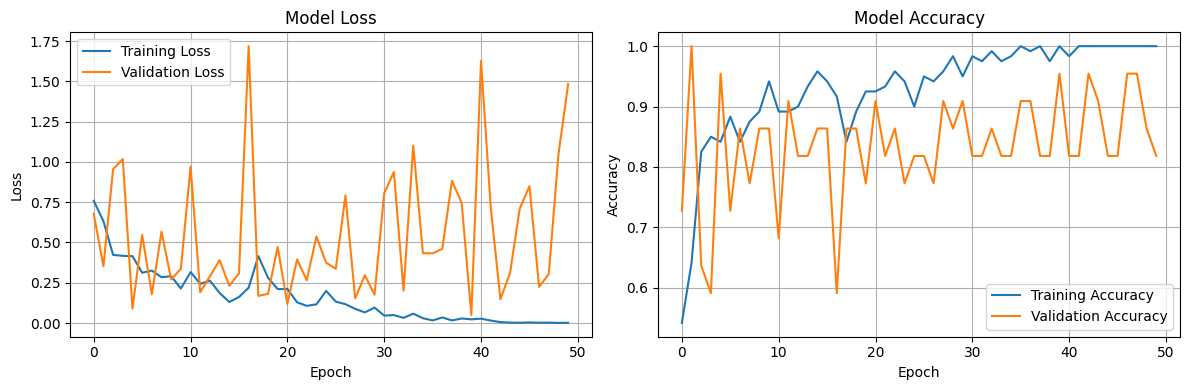

In [17]:
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['sparse_categorical_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_sparse_categorical_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
best_model = keras.saving.load_model('model_custom.keras')

In [19]:
best_model.evaluate(X_test,labels_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.9395 - sparse_categorical_accuracy: 0.8826


[1.2398449182510376, 0.8666666746139526]

In [20]:
# transfer learning

In [21]:
X_train = keras.applications.efficientnet_v2.preprocess_input(images_train)
X_test = keras.applications.efficientnet_v2.preprocess_input(images_test)

In [22]:
pre_model = keras.applications.EfficientNetV2B0(weights='imagenet',include_top=False,input_shape=(128,128,3))

In [23]:
pre_model.summary()

Model: "efficientnetv2-b0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 128, 128, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 128, 128, 3)       │               0 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 64, 64, 32)        │             864 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 64, 64, 32)        │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 64, 64, 32)        │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_project_conv (Conv2D) │ (None, 64, 64, 16)        │           4,608 │ stem_activation[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_project_bn            │ (None, 64, 64, 16)        │              64 │ block1a_project_conv[0][0] │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_project_activation    │ (None, 64, 64, 16)        │               0 │ block1a_project_bn[0][0]   │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2a_expand_conv (Conv2D)  │ (None, 32, 32, 64)        │           9,216 │ block1a_project_activatio… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2a_expand_bn             │ (None, 32, 32, 64)        │             256 │ block2a_expand_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2a_expand_activation     │ (None, 32, 32, 64)        │               0 │ block2a_expand_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2a_project_conv (Conv2D) │ (None, 32, 32, 32)        │           2,048 │ block2a_expand_activation… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2a_project_bn            │ (None, 32, 32, 32)        │             128 │ block2a_project_conv[0][0] │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2b_expand_conv (Conv2D)  │ (None, 32, 32, 128)       │          36,86

 Total params: 5,919,312 (22.58 MB)

 Trainable params: 5,858,704 (22.35 MB)

 Non-trainable params: 60,608 (236.75 KB)

In [24]:
for layer in pre_model.layers:
    layer.trainable = False

In [25]:
pre_model.summary()

Model: "efficientnetv2-b0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 128, 128, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 128, 128, 3)       │               0 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 64, 64, 32)        │             864 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 64, 64, 32)        │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 64, 64, 32)        │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_project_conv (Conv2D) │ (None, 64, 64, 16)        │           4,608 │ stem_activation[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_project_bn            │ (None, 64, 64, 16)        │              64 │ block1a_project_conv[0][0] │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_project_activation    │ (None, 64, 64, 16)        │               0 │ block1a_project_bn[0][0]   │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2a_expand_conv (Conv2D)  │ (None, 32, 32, 64)        │           9,216 │ block1a_project_activatio… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2a_expand_bn             │ (None, 32, 32, 64)        │             256 │ block2a_expand_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2a_expand_activation     │ (None, 32, 32, 64)        │               0 │ block2a_expand_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2a_project_conv (Conv2D) │ (None, 32, 32, 32)        │           2,048 │ block2a_expand_activation… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2a_project_bn            │ (None, 32, 32, 32)        │             128 │ block2a_project_conv[0][0] │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2b_expand_conv (Conv2D)  │ (None, 32, 32, 128)       │          36,86

 Total params: 5,919,312 (22.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 5,919,312 (22.58 MB)

In [26]:
reg = keras.regularizers.l2(0.01)

In [27]:
model = keras.models.Sequential()
model.add(pre_model)
model.add(Flatten())
model.add(Dropout(0.6))
model.add(Dense(2,activation='softmax', kernel_regularizer=reg))

In [28]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)       │ (None, 4, 4, 1280)          │       5,919,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 20480)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 20480)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │          40,962 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,960,274 (22.74 MB)

 Trainable params: 40,962 (160.01 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [29]:
opt = tf.optimizers.Adam(learning_rate=0.001)
loss = tf.losses.SparseCategoricalCrossentropy()
metric = tf.metrics.SparseCategoricalAccuracy()
model.compile(optimizer=opt,loss=loss,metrics=[metric])

In [30]:
callbacks = [keras.callbacks.ModelCheckpoint(filepath='model_pretrain.keras',monitor='val_loss')]

In [31]:
history = model.fit(X_train,labels_train,epochs=20,batch_size=32,validation_split=0.15,verbose=2,callbacks=callbacks)

Epoch 1/20
4/4 - 8s - 2s/step - loss: 0.5111 - sparse_categorical_accuracy: 0.7917 - val_loss: 0.0781 - val_sparse_categorical_accuracy: 1.0000
Epoch 2/20
4/4 - 1s - 253ms/step - loss: 0.0507 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.0476 - val_sparse_categorical_accuracy: 1.0000
Epoch 3/20
4/4 - 1s - 291ms/step - loss: 0.0479 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.0474 - val_sparse_categorical_accuracy: 1.0000
Epoch 4/20
4/4 - 1s - 257ms/step - loss: 0.0475 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.0485 - val_sparse_categorical_accuracy: 1.0000
Epoch 5/20
4/4 - 1s - 273ms/step - loss: 0.0488 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.0493 - val_sparse_categorical_accuracy: 1.0000
Epoch 6/20
4/4 - 1s - 282ms/step - loss: 0.0495 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.0497 - val_sparse_categorical_accuracy: 1.0000
Epoch 7/20
4/4 - 1s - 255ms/step - loss: 0.0498 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.0497 - val_sparse_cat

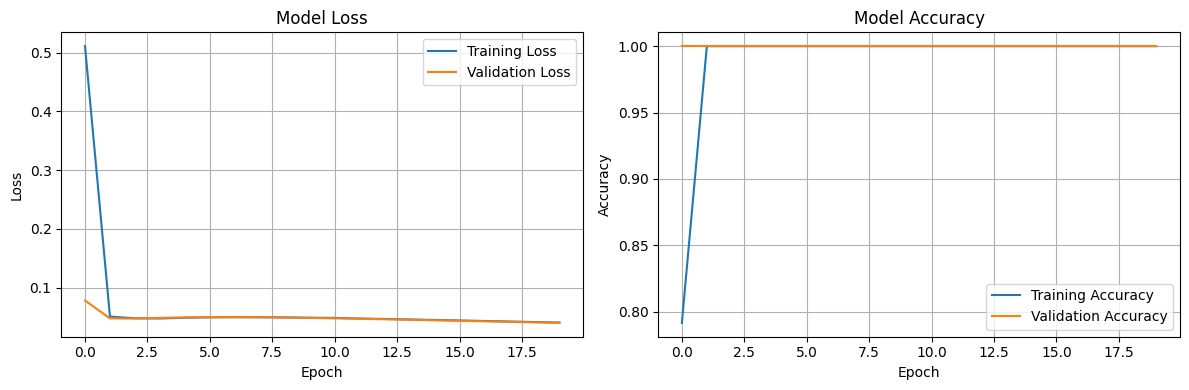

In [32]:
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['sparse_categorical_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_sparse_categorical_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [34]:
best_model = keras.saving.load_model('model_pretrain.keras')

In [35]:
best_model.evaluate(X_test,labels_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - loss: 0.1194 - sparse_categorical_accuracy: 0.9733


[0.09510000795125961, 0.9777777791023254]